# Part 3: Multi-Agent Supervisor

> Objective: This part evaluates the ability to design and implement a multi-agent system  using a supervisor pattern. Using the same data source, you will orchestrate a team of specialised agents to answer a complex query. 


## Step 1: Build the graph

The graph can be found in `src/ai_engineering_assignment/part3/graph.py`

For the multi-agent set up, we will use the subagent multi-agent pattern, where we will send instructions to the two agents in parallel. 

1. When a query comes in, the supervisor receives it and generates a plan. Depending on the query, the supervisor decides which agent(s) are required, then formulates instructions to be sent to the required agent(s). These instructions break down the query and tell the agents what information to look for.

2. The instructions are sent to the relevant agents in parallel, using LangGraph's `Send()` method.

3. Each individual agent first goes through the prepare stage, where it uses the tools available to it to gather the required information.

4. Once an agent has gathered all the required information, it exits the loop and enters the collect stage. In this stage, it extracts the images from the gathered information, to be used for downstream visual grounding.

5. Finally, the results from all agents are synthesized to form the final report.

In [7]:
from IPython.display import Image, display
from ai_engineering_assignment.part3.graph import build_graph
from ai_engineering_assignment.part3.state import ReportState
from ai_engineering_assignment.part3.formatting import format_stream_update
from ai_engineering_assignment.part3.widget import show_widget
from ai_engineering_assignment.settings import MainConfig

configs = MainConfig()

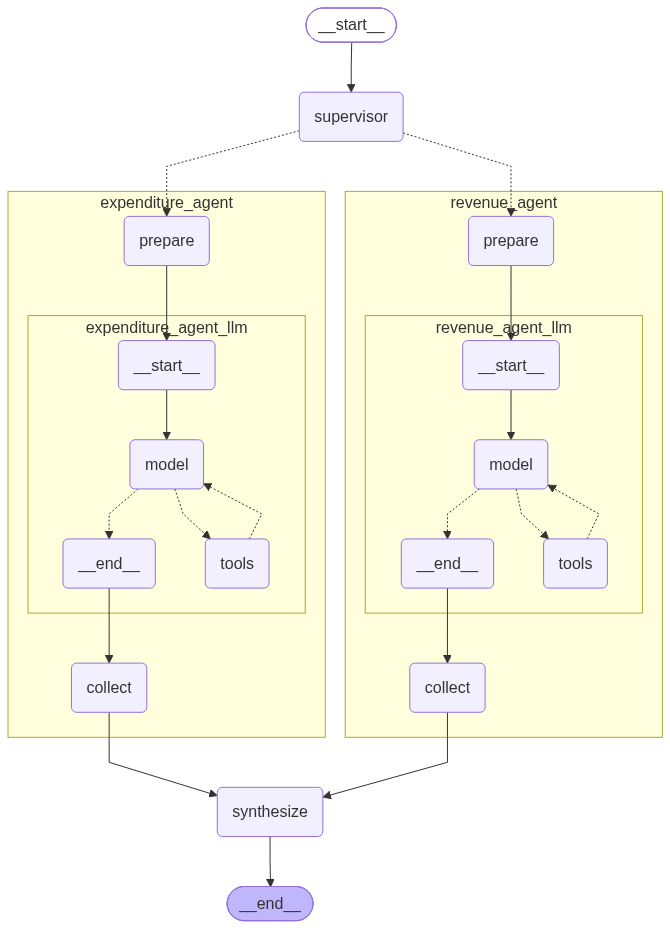

In [2]:
graph = await build_graph()
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

## Step 2: Helper functions to stream and format the output

These are just some helper functions to help with the streaming and formatting of the output

In [3]:
def initial_state(query: str, doc_json_path: str) -> ReportState:
    return {
        "query": query,
        "doc_json_path": doc_json_path,
        "agent_image_paths": {},
        "agent_self_ref_image_paths": {},
        "plan": [],
        "agent_findings": {},
        "final_report": "",
    }

In [4]:
def compact_result(state: ReportState) -> dict:
    # To get the full image_paths across the two agents, we can merge the individual results
    final_self_ref_image_paths = {
        ref: image_path
        for agent_mappings in state["agent_self_ref_image_paths"].values()
        for ref, image_path in agent_mappings.items()
    }

    return {
        "agent_findings": state["agent_findings"],
        "agent_image_paths": state["agent_image_paths"],
        "agent_self_ref_image_paths": state["agent_self_ref_image_paths"],
        "final_self_ref_image_paths": final_self_ref_image_paths,
        "final_report": state["final_report"],
    }

In [5]:
async def stream_report(query: str, doc_json_path: str) -> dict:
    latest_parent_state = None

    async for namespace, stream_mode, chunk in graph.astream(
        initial_state(query=query, doc_json_path=doc_json_path),
        stream_mode=["updates", "values"],
        subgraphs=True,
    ):
        if stream_mode == "updates":
            format_stream_update(namespace, chunk)
        elif stream_mode == "values" and not namespace:
            latest_parent_state = chunk

    if latest_parent_state is None:
        raise RuntimeError(
            "Graph stream completed without returning a final parent state."
        )

    return compact_result(latest_parent_state)

## Step 3: Testing the Queries

#### Query 1: What are the key government revenue streams, and how will the Budget for the Future Energy Fund be supported?

In [8]:
result = await stream_report(
    query="What are the key government revenue streams, and how will the Budget for the Future Energy Fund be supported?",
    doc_json_path=str(configs.ROOT / "data" / configs.app.data.processed),
)


[graph]
├── Node: supervisor
│
├── Supervisor Plan
│   • revenue_agent
│     Identify and extract the key government revenue streams, including all major sources of income such as taxes, fees, and other revenue sources. For each revenue stream, provide details about its magnitude and contribution to total government revenue. Additionally, find specific information about how the Future Energy Fund will be financed and supported, including any dedicated revenue sources or mechanisms allocated to fund this initiative. Include source references for all data points.
│   • expenditure_agent
│     Analyze the spending allocation for the Budget for the Future Energy Fund, including total budget amounts, spending categories, and how resources are distributed. Provide details on the planned expenditures and any financial mechanisms or appropriations supporting this fund. Include source references for all findings.

[revenue_agent]
├── Node: prepare
│
├── 💬 HumanMessage
│     Identify and extrac

In [9]:
# Full generated report
print(result["final_report"])

# COMPREHENSIVE REPORT: GOVERNMENT REVENUE STREAMS AND FUTURE ENERGY FUND FINANCING

---

## EXECUTIVE SUMMARY

**Total Government Revenue (FY2024): $132.14 billion** (#/texts/113, #/texts/115, #/texts/116, #/tables/4)

This report consolidates findings on government revenue composition and the establishment of the Future Energy Fund, a strategic $5.0 billion endowment dedicated to energy transition infrastructure.

---

## 1. TOTAL GOVERNMENT REVENUE COMPOSITION (FY2024)

**Total Government Revenue: $132.14 billion** (#/texts/113, #/texts/115, #/texts/116, #/tables/4)

| Revenue Component | Amount | % of Total |
|---|---|---|
| Operating Revenue | $108.64 billion | 82.0% |
| Net Investment Returns Contribution (NIRC) | $23.5 billion | 18.0% |

The NIRC represents FY2024 budgeted returns from government investment reserves (#/texts/33, #/tables/1, #/tables/8), while FY2023 revised NIRC was $22.9 billion.

---

## 2. OPERATING REVENUE BREAKDOWN

**Total Operating Revenue: $108.64 billio

Here is a widget that allows you to toggle between the different agents and view its findings.

In [10]:
show_widget(result=result)